In [ ]:
# better model for wine qaulity
# 1. Training
#1.a load data

import pandas as pd
df=pd.read_csv("/content/WineQT.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [ ]:
#data analysis
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [ ]:
df.shape

(1143, 13)

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df["quality"].value_counts())

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64


In [ ]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')


In [ ]:
df = df.drop("Id", axis=1)

In [ ]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [ ]:
#splitting the data
x=df[["fixed acidity","volatile acidity","citric acid","residual sugar","chlorides","free sulfur dioxide","total sulfur dioxide","density","pH","sulphates","alcohol"]]
y=df["quality"]
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

#loading model(random forest)
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=300,
    max_depth=None, class_weight='balanced',random_state=42)

# fitting data into model
model=model.fit(xtrain,ytrain)

#testing
op=model.predict(xtest)
op


array([6, 5, 5, 5, 5, 6, 5, 6, 6, 5, 5, 5, 6, 5, 6, 5, 5, 6, 6, 5, 7, 5,
       6, 5, 6, 6, 6, 5, 5, 6, 7, 5, 6, 7, 6, 5, 6, 6, 6, 6, 6, 6, 5, 5,
       6, 6, 6, 6, 6, 6, 5, 6, 6, 7, 5, 6, 5, 6, 6, 6, 6, 5, 5, 5, 5, 6,
       5, 5, 6, 5, 6, 5, 6, 6, 5, 5, 5, 6, 5, 6, 6, 6, 6, 6, 5, 6, 6, 6,
       5, 6, 6, 5, 5, 6, 5, 5, 6, 6, 5, 6, 5, 5, 7, 5, 7, 6, 6, 5, 5, 5,
       5, 5, 6, 6, 6, 6, 5, 5, 5, 5, 7, 6, 6, 5, 5, 6, 6, 7, 5, 7, 6, 5,
       5, 6, 7, 6, 6, 5, 6, 5, 6, 6, 6, 5, 6, 5, 5, 5, 5, 6, 5, 5, 6, 6,
       7, 6, 5, 5, 5, 6, 6, 5, 5, 6, 5, 5, 7, 6, 5, 7, 5, 5, 6, 5, 6, 7,
       5, 6, 7, 5, 5, 5, 5, 6, 5, 5, 6, 6, 5, 5, 5, 5, 6, 5, 7, 5, 6, 5,
       6, 6, 5, 5, 6, 6, 6, 5, 5, 5, 5, 5, 6, 5, 7, 6, 6, 5, 6, 7, 5, 5,
       5, 7, 5, 6, 5, 6, 6, 6, 6])

In [ ]:
from sklearn.metrics import accuracy_score
a=accuracy_score(ytest,op)
print("accuracy score : ",a*100)

accuracy score :  68.5589519650655


In [ ]:
from sklearn.metrics import confusion_matrix
c=confusion_matrix(ytest,op,labels=model.classes_)
print("confusion matrix:",c)

confusion matrix: [[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 77 20  0  0]
 [ 0  0 23 65  4  0]
 [ 0  0  2 12 15  0]
 [ 0  0  0  3  0  0]]


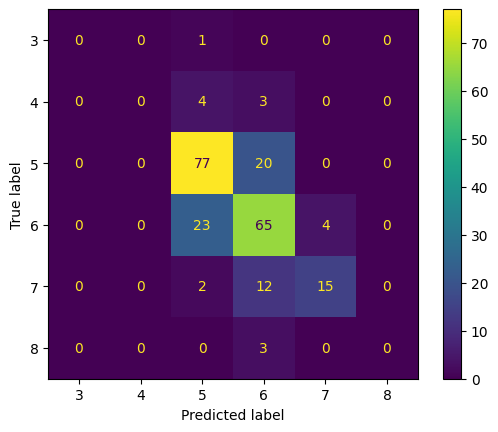

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
co=ConfusionMatrixDisplay(confusion_matrix=c,display_labels=model.classes_)
co.plot()

In [ ]:
from sklearn.metrics import classification_report
wine_names = ['wine quality 3', 'wine quality 4','wine quality 5','wine quality 6','wine quality 7','wine quality 8']
ca=classification_report(ytest,op,)
print(classification_report(ytest,op, target_names=wine_names))



                precision    recall  f1-score   support

wine quality 3       0.00      0.00      0.00         1
wine quality 4       0.00      0.00      0.00         7
wine quality 5       0.72      0.79      0.75        97
wine quality 6       0.63      0.71      0.67        92
wine quality 7       0.79      0.52      0.62        29
wine quality 8       0.00      0.00      0.00         3

      accuracy                           0.69       229
     macro avg       0.36      0.34      0.34       229
  weighted avg       0.66      0.69      0.67       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
from sklearn.metrics import f1_score

macrof1 = f1_score(ytest, op, average='macro')
print(f"Macro F1 Score: {macrof1:2f}")

weightedf1 = f1_score(ytest, op, average='weighted')
print(f"Weighted F1 Score: {weightedf1:2f}")

microf1=f1_score(ytest,op,average='micro')
print(f"minimum f1 score:{microf1:2f}")


Macro F1 Score: 0.341095
Weighted F1 Score: 0.666742
minimum f1 score:0.685590
